# Preparation for interpolation

Confidence interval version

In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Preparation interpolation

search F range 

In [2]:
sigma_rsl = 2000
Sigmas = np.linspace(0.01, 6.0, sigma_rsl)
# Sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(Sigmas), np.max(Sigmas)])

C0s = np.zeros_like(Sigmas)
As = np.zeros_like(Sigmas)
Vars_sqrt = np.zeros_like(Sigmas)

pbar = tqdm(Sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = find_C0_sigma(sigma,
                 condition='median'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Vars_sqrt[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        sigma2=calc_confidence_interval_width(sigma=sigma, C_0=C0, A=A, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              )
        Vars_sqrt[i] = sigma2/4

[0.01, 6.0]


Processing sigma=6.0000: 100%|██████████| 2000/2000 [12:18<00:00,  2.71it/s]


In [ ]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Vars_sqrt)
C0s = C0s[mask]
As = As[mask]
Vars_sqrt = Vars_sqrt[mask]
Sigmas = Sigmas[mask]
print(len(Sigmas), len(C0s), len(As), len(Vars_sqrt))

2000 2000 2000 2000


In [ ]:
# sigma_rsl=5000
# # Sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# Sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(Sigmas),np.max(Sigmas)])
# C0s=np.zeros_like(Sigmas)
# As=np.zeros_like(Sigmas)
# Vars_sqrt=np.zeros_like(Sigmas)
# for i, sigma in enumerate(Sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Vars_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

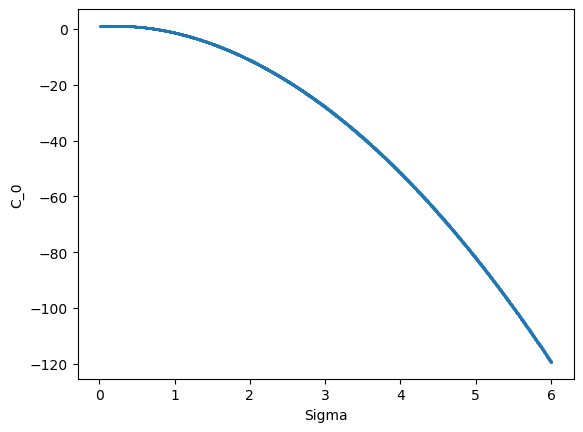

In [ ]:
plt.scatter(Sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

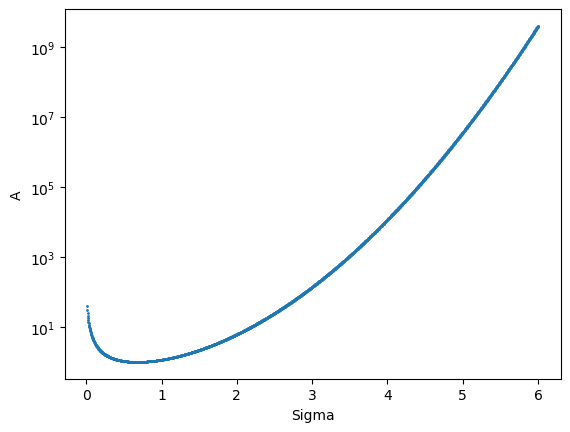

In [ ]:
plt.scatter(Sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

Text(0.5, 0, 'Variance_sqrt')

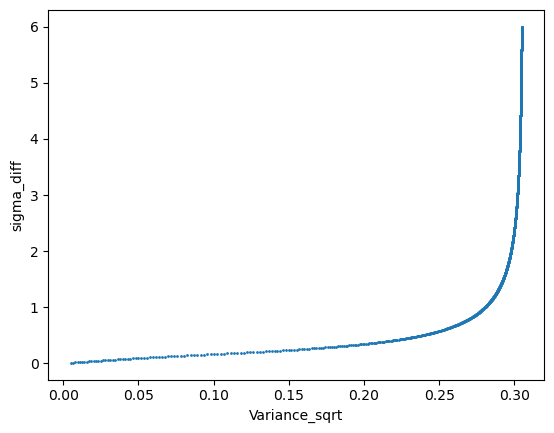

In [ ]:
plt.scatter(Vars_sqrt, Sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
# plt.xlim(0.7, 0.8)
# plt.xscale('log')
# plt.yscale('log')

Text(0.5, 0, 'Sigma')

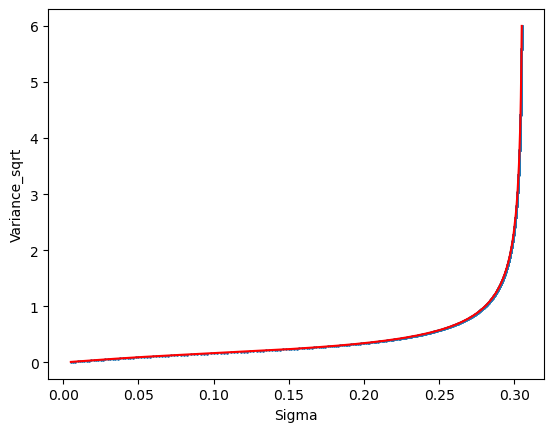

In [ ]:
inter_sigma=interpolate.interp1d(Sigmas, Vars_sqrt, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
re_sigmas=np.linspace(np.min(Sigmas), np.max(Sigmas), 2*sigma_rsl)
re_var_sqrt=inter_sigma(re_sigmas)
plt.plot(re_var_sqrt, re_sigmas, 'r-', label='interpolated')
plt.scatter(Vars_sqrt, Sigmas, s=1, label='original')
plt.ylabel('Variance_sqrt')
plt.xlabel('Sigma')

In [ ]:
np.savez('./interpolation/068_C0median.npz', a=Sigmas, b=As, c=C0s, d=Vars_sqrt)

In [2]:
load_arrays=np.load('./interpolation/068_C0median.npz')
Sigmas=load_arrays['a']
Vars_sqrt=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

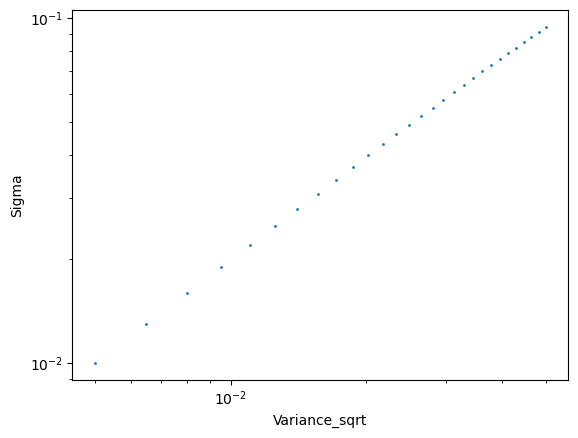

In [3]:
fit_vars_sqrt=Vars_sqrt[Vars_sqrt<=0.05]
fit_Sigmas=Sigmas[Vars_sqrt<=0.05]
plt.scatter(fit_vars_sqrt, fit_Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Variance_sqrt')
plt.xscale('log')
plt.yscale('log')

In [19]:
log_vars_sqrt=np.log10(fit_vars_sqrt)
log_Sigmas=np.log10(fit_Sigmas)

def fit_fun(x, b):
    return x+b

popt, pcov = curve_fit(fit_fun, log_vars_sqrt, log_Sigmas)
print(popt)
b=popt[0]
c=10**b
print(c)

[0.29135897]
1.955955484268727


In [20]:
print(np.sqrt(0.025)*c)

0.309263716609341


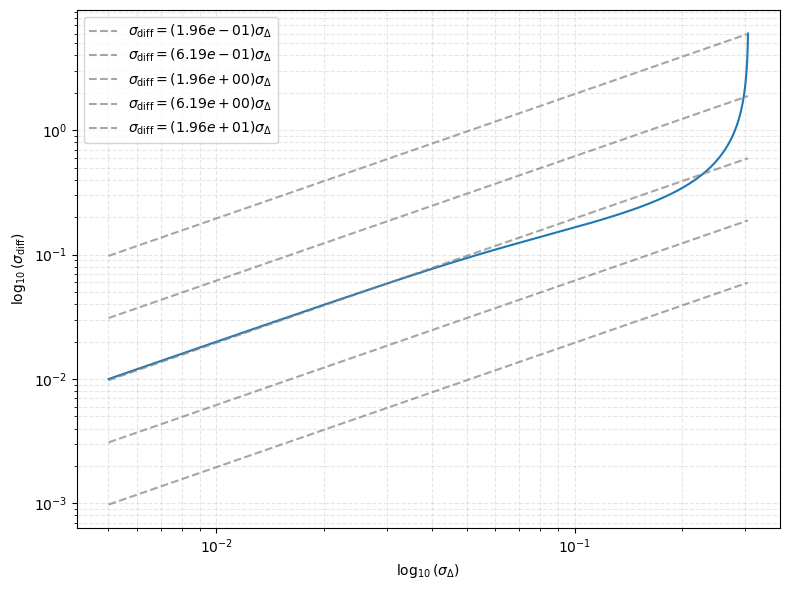

In [27]:
plt.figure(figsize=(8, 6))
# plt.scatter(Vars_sqrt, Sigmas,s=0.5)
plt.plot(Vars_sqrt, Sigmas)
plt.ylabel(r'$\log_{10} (\sigma_{\rm diff})$')
plt.xlabel(r'$\log_{10} (\sigma_\Delta)$')
plt.xscale('log',base=10)
plt.yscale('log',base=10)

x_min = min(Vars_sqrt)
x_max = max(Vars_sqrt)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

constants = [b-1, b-0.5, b, b+0.5, b+1]
for c in constants:
    const=(10**c)
    y_ref = x_range * const  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' ({const:.2e})'+r'\sigma_\Delta $')

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./plot/sigma_diff_vs_sigma_delta.png', dpi=300)

In [10]:
print(Vars_sqrt)

[0.00500319 0.00650519 0.00800935 ... 0.30493488 0.30493865 0.30493922]


In [ ]:
# interpolation example

# C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Vars_sqrt, Sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [ ]:
# np.save('./interpolation/Sigmas.npy', Sigmas)
# np.save('./interpolation/As.npy', As)
# np.save('./interpolation/C0s.npy', C0s)
# np.save('./interpolation/Vars_sqrt.npy', Vars_sqrt)